In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset("penguins")
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


- Категориальные: `species`, `island`, `sex`
- Числовые : `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`

1. Сколько наблюдений (пингвинов) - 344; признаков - 7
2. Сколько пропусков в каждой колонке? 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


Удали все строчки с прпоусками (если строчка содержит хотя бы 1 пропуск -- ее удаляем)

`.countplot()` = `.value_counts().plot(kind='bar')` - с **категориальными** признаками
- `hue` - категориальный [обычно]

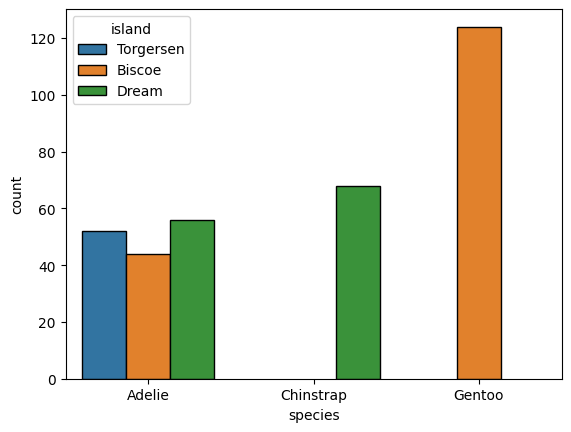

In [9]:
# сколько в каждой категории наблюдений
sns.countplot(data=df, x="species", hue="island", edgecolor="k")
# .value_counts().plot(kind='bar')
plt.show()

`boxplot()` = `.plot(kind='box')`

In [10]:
# медиана, q1, q3; границы выбросов
# x - числовой признак

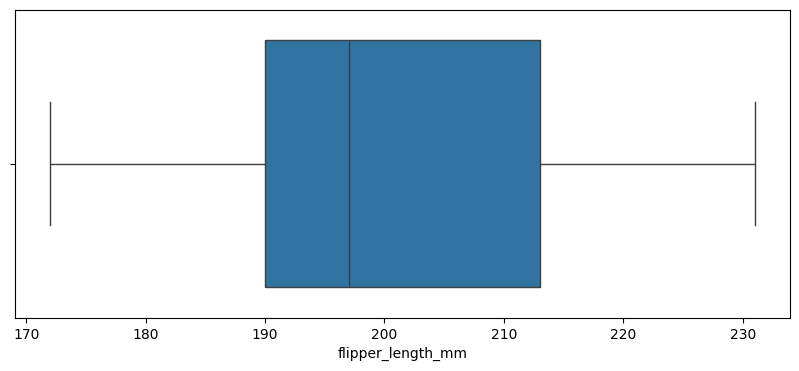

In [11]:
# по всем пингвинам
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="flipper_length_mm",  # x - числовой признак, по к-му смотрим статистики
)

plt.show()

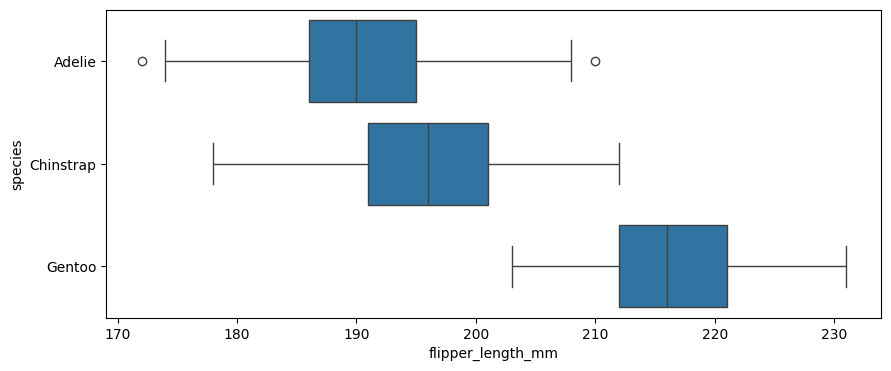

In [12]:
# три боксплота - по каждому из пингвинов
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="flipper_length_mm",  # x - числовой признак, по к-му смотрим статистики
    y="species",
)

plt.show()

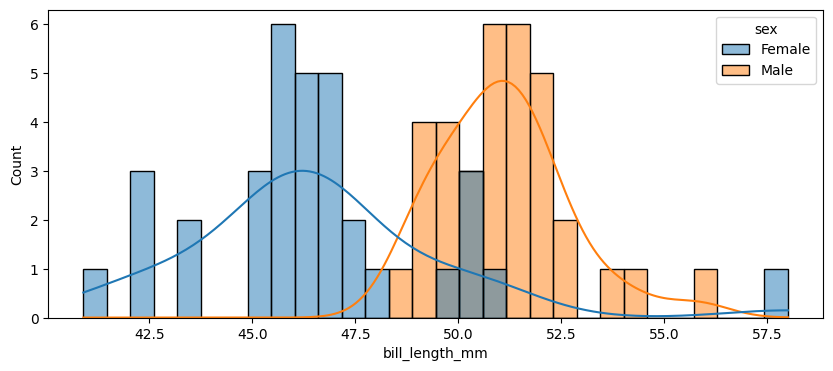

In [14]:
# три боксплота - по каждому из пингвинов
plt.figure(figsize=(10, 4))

sns.histplot(
    data=df[df["species"] == "Chinstrap"],
    x="bill_length_mm",
    hue="sex",
    bins=30,
    kde=True,  # kernel density function
)

plt.show()

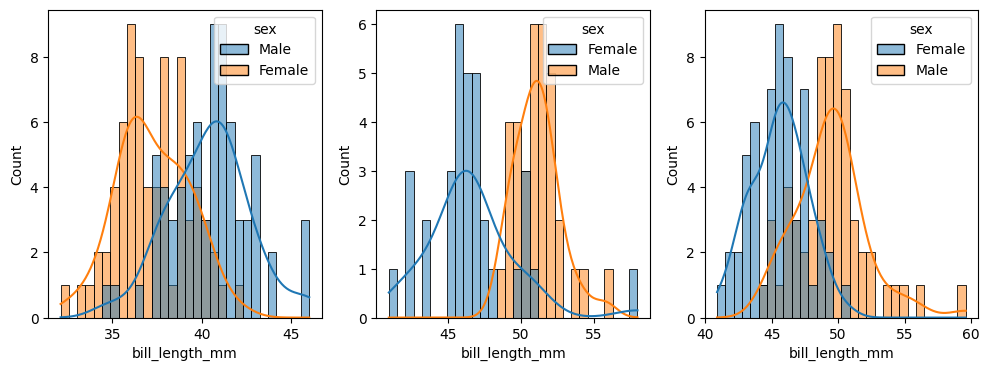

In [15]:
# три боксплота - по каждому из пингвинов
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

sp = df["species"].unique()

for i in range(3):
    sns.histplot(
        data=df[df["species"] == sp[i]],
        x="bill_length_mm",
        hue="sex",
        bins=30,
        kde=True,  # kernel density function
        ax=axs[i],  # вместо axs[i].plot(....)
    )

plt.show()

scatterplot = диаграмма рассеяния
- для двух числовых признаков
- одна точка = одно наблюдение (один пингвин)
- увидеть зависимость одного признака от второго

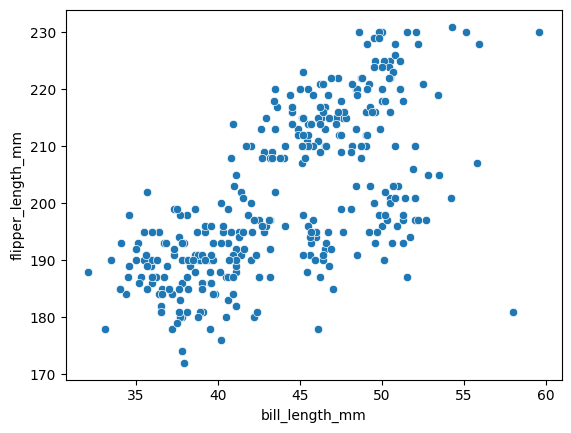

In [ ]:
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm",
)

plt.show()

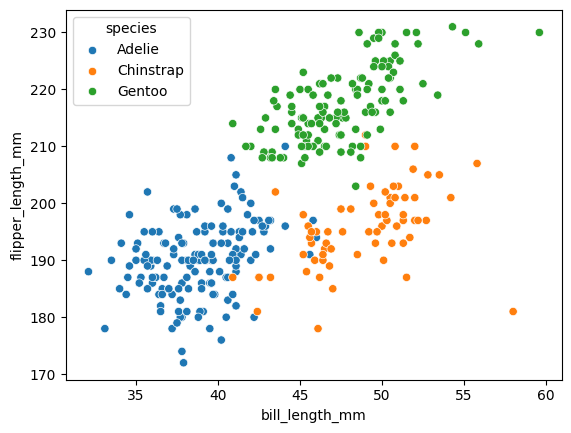

In [ ]:
# нужно покрасить точки - каждый в свой вид пингвина
sns.scatterplot(data=df, x="bill_length_mm", y="flipper_length_mm", hue="species")
plt.show()

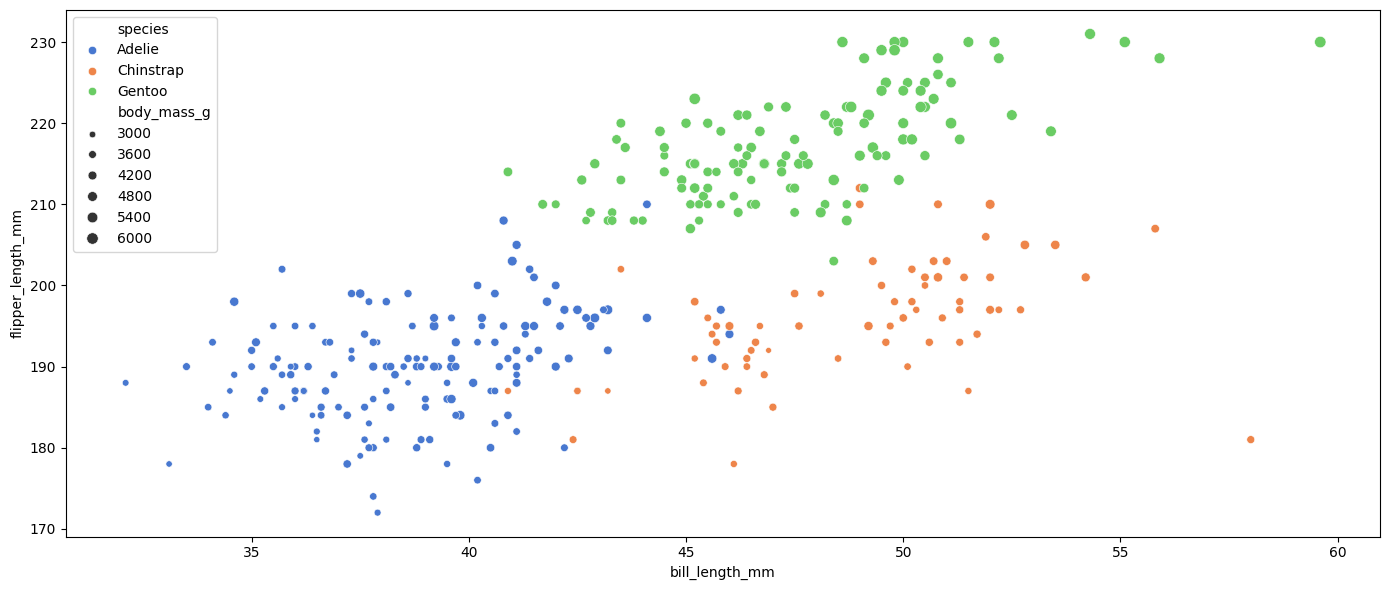

In [ ]:
plt.figure(figsize=(14, 6))

sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    size="body_mass_g",
    palette="muted",
)

plt.tight_layout()
plt.show()

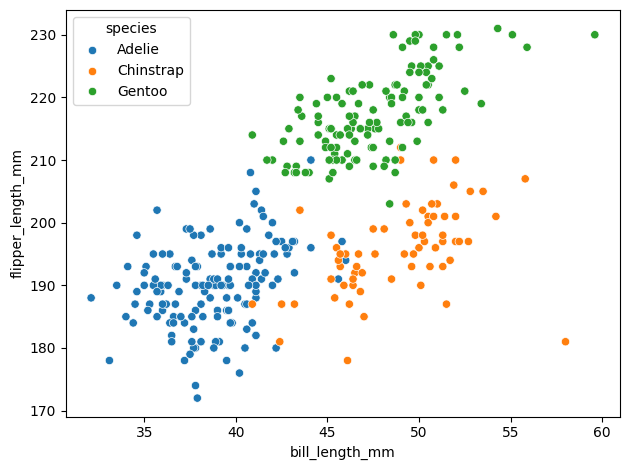

In [46]:
# plt.figure(figsize=(14, 6))

sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
)

plt.tight_layout()
plt.show()

**Корреляция** - показывает, насколько признаки сонаправлены друг с другом
- нет причинно-следственной связи
- от -1 до +1.
    - чем ближе к +1 или -1 -- тем сильнее связь
    - чем ближе к нулю - тем слабее связь
    - положительные значения одзначают положительную корреляцию: с увеличением одного признака - второй тоже увеличивается
    - отрицательные значения одзначают отрицательную корреляцию: с увеличением одного признака - второй уменьшается
- считается только для ЧИСЛОВЫХ значений

Матрица корреляций:
- показывает как каждый числовой признак связан с каждым другим признаком
- она симметричная относительно диагонали 
- по диагонали стоят 1 - автокорреляция (признак сам с собой)

In [44]:
df.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


Как интерпретировать [по модулю]:
- Больше 0.8 - очень сильная зависимость
- От 0.5 до 0.8 - норм зависимость
- от 0.2 до 0.5 - слабая, но есть
- меньше 0.2 - считаем что зависимости нет

>**TASK**: посмотреть на корреляции всех признаков со всеми отдельно для каждого вида пингвина. Есть гипотеза, что корреляция в срезе по виду пингвина сильнее, чем обобщенная
>- завести список с видами пингвинов
>- в цикле пройтись по каждому виду пингвина
>    - отфильтровать таблицу по этому виду пингвина = оставить только наблюдения с текущим видом
>    - посчитать таблицу корреляций (напечатать)

In [ ]:
species = df["species"].unique()

for s in species:
    display(df[df["species"] == s].corr(numeric_only=True))

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,0.391492,0.325785,0.548866
bill_depth_mm,0.391492,1.000000,0.307620,0.576138
flipper_length_mm,0.325785,0.307620,1.000000,0.468202
body_mass_g,0.548866,0.576138,0.468202,1.000000


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,0.653536,0.471607,0.513638
bill_depth_mm,0.653536,1.000000,0.580143,0.604498
flipper_length_mm,0.471607,0.580143,1.000000,0.641559
body_mass_g,0.513638,0.604498,0.641559,1.000000


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,0.643384,0.661162,0.669166
bill_depth_mm,0.643384,1.000000,0.706563,0.719085
flipper_length_mm,0.661162,0.706563,1.000000,0.702667
body_mass_g,0.669166,0.719085,0.702667,1.000000


**heatmap** (тепловая карта) - позволяет визуализировать любые таблицы (или матрицы), где есть ТОЛЬКО ЧИСЛА

>**TASK**: построить три heatmap - один для каждого вида

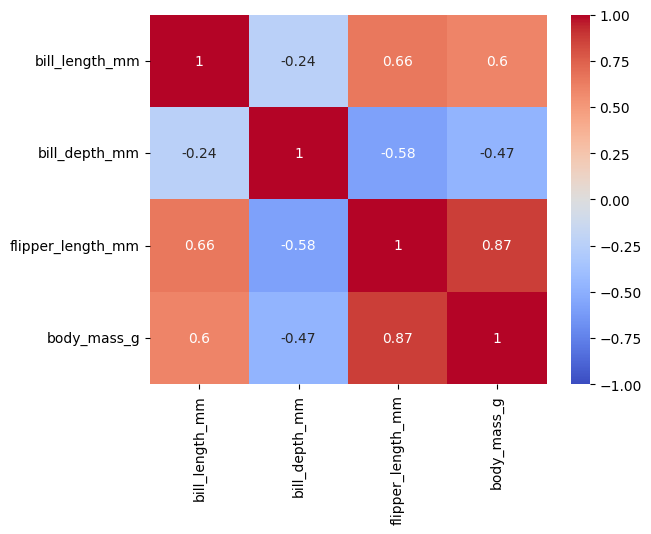

In [ ]:
corr_df = df.corr(numeric_only=True)


sns.heatmap(data=corr_df, vmin=-1, vmax=1, cmap="coolwarm", annot=True)

plt.show()

---

Базовый код для оформления графиков (шаблон)

In [ ]:
plt.figure(figsize=(8, 6))

# построение графика (matplotlib / seaborn)
# matplotlib:
# - plt.hist(....)
# - plt.bar(....)
# - plt.box(....)
# seaborn:
# - sns.histplot(....)
# - sns.barplot(....)
# - sns.boxplot(....)

plt.title("Название")
plt.xlabel("Название оси OX")  #  автоматически берется из колонки для seaborn
plt.ylabel("Название оси OY")  #  автоматически берется из колонки для seaborn

# если нужна легенда
# если есть какие-то label в matplotlib или seaborn (когда помечаем разные категории н-р разным цветом)
plt.legend(title="Название легенды")

# для более крсивого оформления
plt.tight_layout()

plt.show()

Если графиков несколько (создаем сетку)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(14, 6))

# построение графика (matplotlib / seaborn)
for x in range(3):
    #   matplotlib:
    #       - axs[x].hist(....)
    #       - axs[x].bar(....)
    #       - axs[x].box(....)
    #   seaborn:
    #       - sns.histplot(...., ax = axs[x])
    #       - sns.barplot(...., ax = axs[x])
    #       - sns.boxplot(...., ax = axs[x])
    #
    #   название подграфика
    axs[x].set_title("Название")
    axs[x].set_xlabel("Название оси OX")
    axs[x].set_ylabel("Название оси OY")


# если нужна легенда
# если есть какие-то label в matplotlib или seaborn (когда помечаем разные категории н-р разным цветом)
plt.legend(title="Название легенды")

# для более крсивого оформления
plt.tight_layout()

plt.show()

----

Хотим построить три хитмапа, каждый по своему виду пингвина

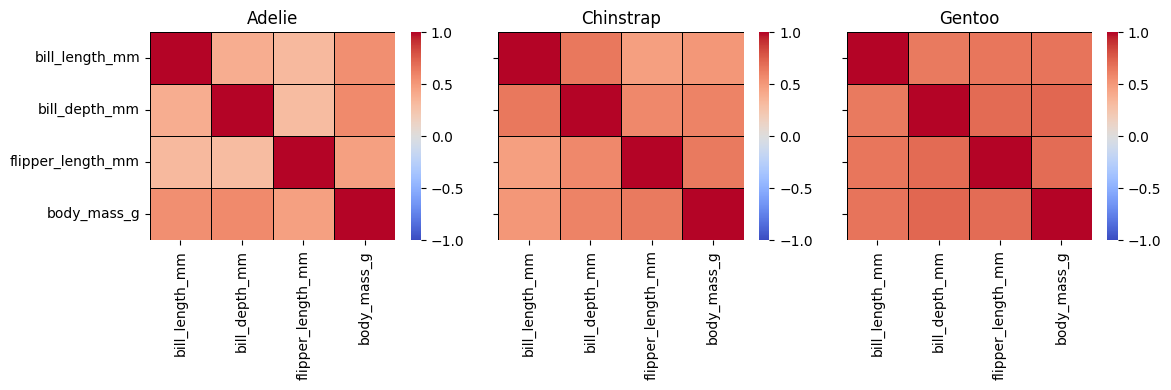

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

# все виды
species = df["species"].unique()

for x in range(3):  # 0 1 2
    sp = species[x]  #  текущий вид (из списка species)
    df_sp = df[df["species"] == sp]  # таблица где есть только текущий вид
    corr_df_dp = df_sp.corr(numeric_only=True)
    sns.heatmap(
        corr_df_dp,
        ax=axs[x],
        vmin=-1,
        vmax=1,
        cmap="coolwarm",
        linecolor="k",
        linewidths=0.5,
    )
    axs[x].set_title(sp)

plt.tight_layout()
plt.show()